[[-1.10000000e+03 -5.45696821e-11  1.96446976e+05]]
Mittelpunkt = (549.9999999999992,2.7284841053187847e-11)
Radius = 325.6578319406335
keine Aussage möglich


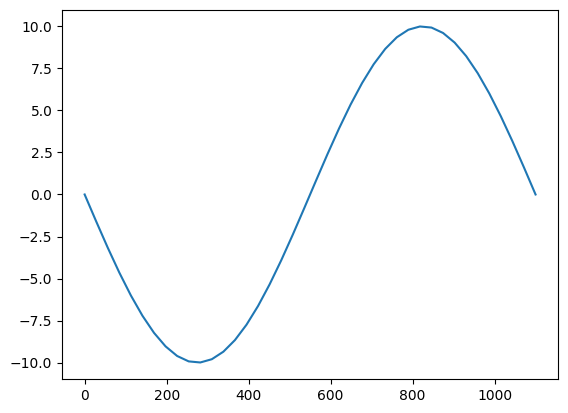

In [ ]:
import numpy as np
from math import sqrt,sin,pi
import matplotlib.pyplot as plt


l = 1100
b = 360
t = 3.6
step = 40

"""
wollen längs der x-Achse, auf Höhe von y/2, also egl b/2y, die Krümmung analysieren 
wir bilden also einen Array mit (x,z) Werten, machen ein Circle-Fitting und analysieren die krümmung abhängig davon ob der erhaltene Kreismittelpunkt oberhalb der platte oder unterhalb liegt
"""

# aus xyz-File
"""
filename_messwerte = f"{t}mm_messwerte.xyz"
data_messwerte = np.loadtxt(filename_messwerte)

array100 = np.full(1600,100)

x_SW = data_messwerte[:,0]
y_SW = data_messwerte[:,1]
z_SW = data_messwerte[:,2] - array100

step_mitte = round((step+1)/2)      # breite/2, auf mittlerer höhe
Start_index = step*(step_mitte-1)

x_Werte = x_SW[Start_index:(Start_index+step)]
z_Werte = z_SW[Start_index:(Start_index+step)]
"""

def f(x):
    return -10*sin(2*pi*x/l)

# selbst generierte Werte
x_Werte = np.linspace(0,l,step)
z_Werte = [f(x) for x in x_Werte]
#print(x_Werte)
#print(z_Werte)

plt.plot(x_Werte,z_Werte)
# plt.show()


# region CIRCLE FITTING ALGORITHM
"""
- Gleichung:
    x²+y²+Dx+Ey+F = r² 
- umwandeln zu:
    Dx+Ey+F = -(x²+y²)
    -> also LGS bzgl (D,E,F)
D = -2x_c
E = -2y_c
F = x_c² + y_c² -r²

- erhalten Mittelpunkt und Radius eines Kreises:
x_c = -D/2
y_c = -E/2
r = sqrt(F-(x_c²+y_c²))
"""

xz_Array = [ [float(x),float(z)] for x,z in zip(x_Werte,z_Werte) ]      # (x,z) entlang der linie

A_mat = np.matrix([   [entry[0],entry[1],1] for entry in xz_Array    ])        #ist bereits transponierte Matrix
AT_mat = np.matrix.transpose(A_mat)
b_vec = [-(x**2+z**2) for (x,z) in xz_Array]


# zu lösen: (AT*A)x = AT*b <=> x = (AT*A)^(-1)*AT*b
AT_A_mat = AT_mat * A_mat
AT_A_invers = np.linalg.inv(AT_A_mat)
x = AT_A_invers * AT_mat @ b_vec

print(x)        # x = [D,E,F]

D = x[0,0]
E = x[0,1]
F = x[0,2]

# endregion

X_Mittelpunkt = -D/2
Z_Mittelpunkt = -E/2
Radius = sqrt( ( X_Mittelpunkt**2 + Z_Mittelpunkt**2 ) - F )

print(f"Mittelpunkt = ({X_Mittelpunkt},{Z_Mittelpunkt})\nRadius = {Radius}")

# daraus analysieren, ob positiv oder negativ gekrümmt
tol = 10e-11        # bei sinus-kurve ab 10e-12 meinte negativ gekrümmt, also ab dieser toleranz falsch
if Z_Mittelpunkt >= tol:
    print("positiv gekrümmt")

elif Z_Mittelpunkt <= -tol:
    print("negativ gekrümmt")
else:
    print("keine Aussage möglich")
